# Classifier Evaluation

Runs our XGBoost classifier on the full dataset and compares:
1. **GT vs C4** â€” confusion matrix, per-class accuracy & F1
2. **Clf vs C4** â€” confusion matrix, per-class % agreement
3. **Disagreement examples** â€” for each class, 9 high-confidence clf predictions that disagree with C4; plots WF + 1D ACG

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
from pathlib import Path

pkg_parent = Path().resolve().parent.parent
if str(pkg_parent) not in sys.path:
    sys.path.insert(0, str(pkg_parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)

from cerebellum_cell_classifier.classifier import load_model_folder, run_inference
from cerebellum_cell_classifier.autoencoders.transforms import normalize_waveforms
from cerebellum_cell_classifier.gui.data_store import SessionData

print('imports OK')

imports OK


In [2]:
DATASET_DIR   = Path(r'Z:\loco\cell_class\datasets')
MODEL_FOLDER  = Path('../checkpoints/final_clf')

CLASSES      = ['CF', 'MF', 'PC', 'others']
CLASS_COLORS = {'PC': '#2196F3', 'CF': '#F44336', 'MF': '#FF9800', 'others': '#4CAF50', 'unknown': '#9E9E9E'}

# C4 label â†’ our 4-class scheme
C4_MAP = {
    'PkC_ss': 'PC',
    'PkC_cs': 'CF',
    'MFB':    'MF',
    'MLI':    'others',
    'GoC':    'others',
}

NPZ_PATHS = sorted(DATASET_DIR.rglob('*_features.npz'))
print(f'Found {len(NPZ_PATHS)} sessions')

Found 31 sessions


In [3]:
# Load model (PyTorch if available, else onnxruntime)
models = load_model_folder(MODEL_FOLDER)
print(f'Backend: {models["backend"]}')

Backend: torch


In [4]:
def assign_gt(label, c4):
    """Ground-truth class: manual labels first, then C4 for MLI/GoC â†’ others."""
    if label in ('PC', 'CF', 'MF'):
        return label
    if c4 in ('MLI', 'GoC'):
        return 'others'
    return 'unknown'


all_rows = []

for npz_path in NPZ_PATHS:
    try:
        sd = SessionData(str(npz_path))
    except Exception as e:
        print(f'  SKIP {npz_path.name}: {e}')
        continue

    # Run our classifier
    clf_labels, clf_conf = run_inference(sd, models)

    # Load manual labels from sidecar CSV
    stem = npz_path.stem.replace('_features', '')
    lbl_path = npz_path.parent / f'{stem}_labels.csv'
    manual = {}
    if lbl_path.exists():
        ldf = pd.read_csv(lbl_path)
        manual = dict(zip(ldf['unit_id'].astype(int), ldf['label'].astype(str)))

    for i in range(sd.n_units):
        uid   = int(sd.unit_ids[i])
        label = manual.get(uid, str(sd.labels[i]))
        c4_raw = sd.get_c4_pred(i)          # raw C4 string, e.g. 'PkC_ss'
        c4_cls = C4_MAP.get(c4_raw, 'unknown')
        gt_cls = assign_gt(label, c4_raw)

        all_rows.append({
            'session':   sd.session_name,
            'unit_id':   uid,
            'arr_i':     i,
            'npz_path':  str(npz_path),
            'gt_class':  gt_cls,
            'c4_raw':    c4_raw,
            'c4_class':  c4_cls,
            'clf_class': str(clf_labels[i]),
            'clf_conf':  float(clf_conf[i]),
        })

    print(f'  {npz_path.stem:50s}  {sd.n_units} units')

df = pd.DataFrame(all_rows)
print(f'\nTotal units: {len(df)}')
print(df[['gt_class','c4_class','clf_class']].apply(pd.Series.value_counts).fillna(0).astype(int))

  AA11_01_features                                    168 units


  AA11_02_features                                    214 units


  AA11_08_features                                    122 units


  AA11_10_features                                    187 units


  AA23_01_features                                    240 units


...

  XG037_20250804_4_OF_g0_imec0_features               120 units
  catgt_XG046_20260208_g0_features                    59 units


  catgt_XG046_20260204_shank1_g0_features             90 units


  catgt_XG046_20260205_g0_features                    108 units


  catgt_XG047_20260220_shank1_2_g0_features           134 units


  catgt_XG048_20260217_all_deep_g0_features           123 units

Total units: 6076
         gt_class  c4_class  clf_class
CF           1168      1237       1701
MF            432      2529       2333
PC            155       424        426
others        628       655       1616
unknown      3693      1231          0


---
## 1. GT vs C4 predictions

Units with both GT and C4 label: 2137
gt_class
CF        979
others    628
MF        398
PC        132
Name: count, dtype: int64


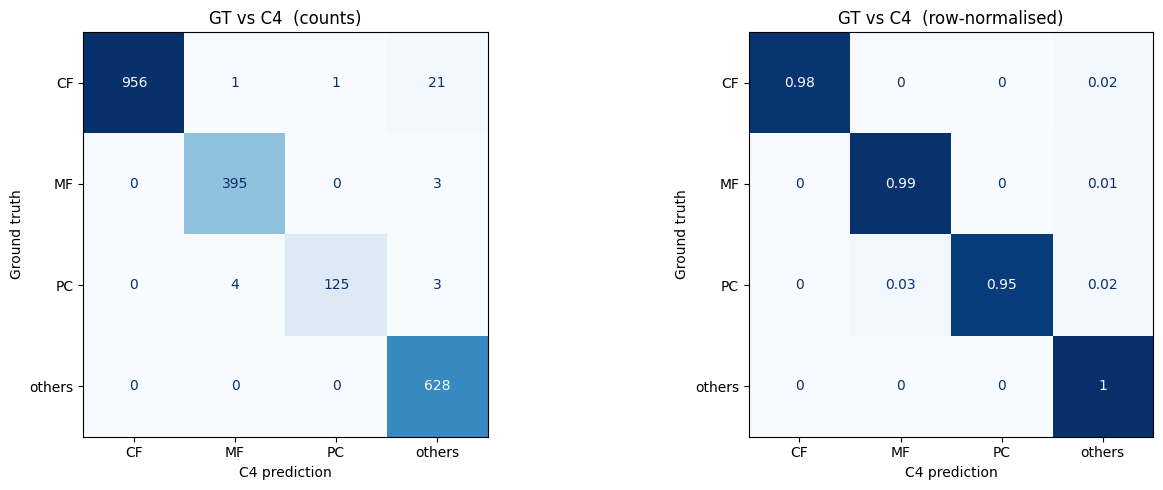


Overall accuracy : 0.985
Weighted F1      : 0.985

Class           F1    N GT
CF           0.988     979
MF           0.990     398
PC           0.969     132
others       0.979     628


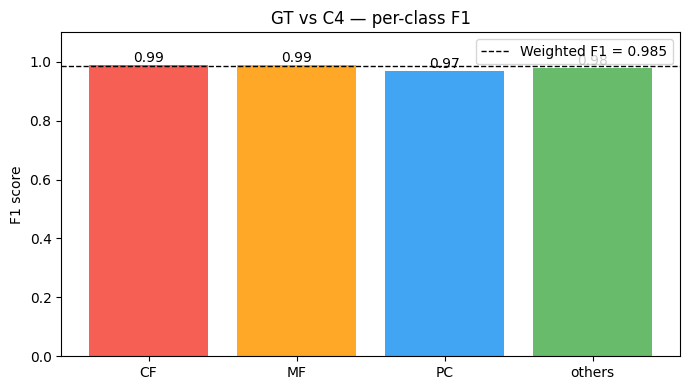

In [5]:
# Use only units with both a GT label and a C4 prediction
df1 = df[(df['gt_class'] != 'unknown') & (df['c4_class'] != 'unknown')].copy()
print(f'Units with both GT and C4 label: {len(df1)}')
print(df1['gt_class'].value_counts())

y_true = df1['gt_class'].values
y_pred = df1['c4_class'].values

# â”€â”€ Confusion matrix â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('GT vs C4  (counts)', fontsize=12)
axes[0].set_xlabel('C4 prediction')
axes[0].set_ylabel('Ground truth')

# Normalised (recall per GT class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASSES)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('GT vs C4  (row-normalised)', fontsize=12)
axes[1].set_xlabel('C4 prediction')
axes[1].set_ylabel('Ground truth')

plt.tight_layout()
plt.show()

# â”€â”€ Per-class metrics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
overall_acc = accuracy_score(y_true, y_pred)
overall_f1  = f1_score(y_true, y_pred, average='weighted', labels=CLASSES, zero_division=0)
f1_per     = f1_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)

print(f'\nOverall accuracy : {overall_acc:.3f}')
print(f'Weighted F1      : {overall_f1:.3f}')
print()
print(f'{"Class":<10}  {"F1":>6}  {"N GT":>6}')
for cls, f1 in zip(CLASSES, f1_per):
    n = (df1['gt_class'] == cls).sum()
    print(f'{cls:<10}  {f1:6.3f}  {n:6d}')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASSES, f1_per, color=[CLASS_COLORS[c] for c in CLASSES], alpha=0.85)
for bar, v in zip(bars, f1_per):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.2f}', ha='center', fontsize=10)
ax.axhline(overall_f1, color='k', ls='--', lw=1, label=f'Weighted F1 = {overall_f1:.3f}')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 score')
ax.set_title('GT vs C4 â€” per-class F1', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Our classifier vs C4 predictions

Units with C4 prediction: 4845


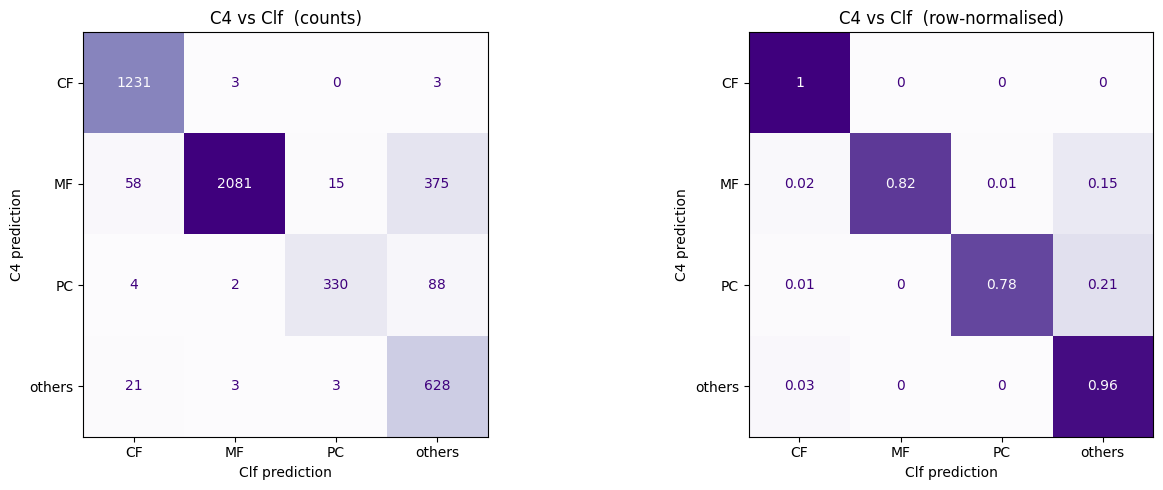


Class        Agreement    N C4
CF               99.5%    1237
MF               82.3%    2529
PC               77.8%     424
others           95.9%     655

Overall agreement: 88.1%


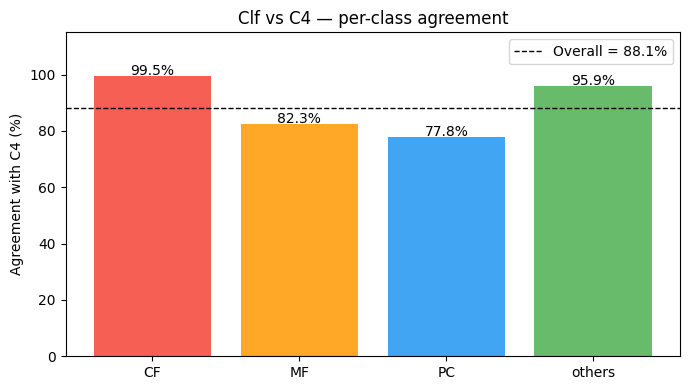

In [6]:
# Use all units that have a C4 prediction
df2 = df[df['c4_class'] != 'unknown'].copy()
print(f'Units with C4 prediction: {len(df2)}')

y_true2 = df2['c4_class'].values
y_pred2 = df2['clf_class'].values

# â”€â”€ Confusion matrix â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm2 = confusion_matrix(y_true2, y_pred2, labels=CLASSES)
ConfusionMatrixDisplay(cm2, display_labels=CLASSES).plot(
    ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('C4 vs Clf  (counts)', fontsize=12)
axes[0].set_xlabel('Clf prediction')
axes[0].set_ylabel('C4 prediction')

cm2_norm = cm2.astype(float) / cm2.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(np.round(cm2_norm, 2), display_labels=CLASSES).plot(
    ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('C4 vs Clf  (row-normalised)', fontsize=12)
axes[1].set_xlabel('Clf prediction')
axes[1].set_ylabel('C4 prediction')

plt.tight_layout()
plt.show()

# â”€â”€ Per-class % agreement â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print(f'\n{"Class":<10}  {"Agreement":>10}  {"N C4":>6}')
agreements = []
for cls in CLASSES:
    mask = df2['c4_class'] == cls
    n    = mask.sum()
    if n == 0:
        agreements.append(0.0)
        print(f'{cls:<10}  {"N/A":>10}  {0:6d}')
    else:
        agree = (df2.loc[mask, 'clf_class'] == cls).mean() * 100
        agreements.append(agree)
        print(f'{cls:<10}  {agree:9.1f}%  {n:6d}')

overall_agree = (df2['clf_class'] == df2['c4_class']).mean() * 100
print(f'\nOverall agreement: {overall_agree:.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASSES, agreements, color=[CLASS_COLORS[c] for c in CLASSES], alpha=0.85)
for bar, v in zip(bars, agreements):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=10)
ax.axhline(overall_agree, color='k', ls='--', lw=1, label=f'Overall = {overall_agree:.1f}%')
ax.set_ylim(0, 115)
ax.set_ylabel('Agreement with C4 (%)')
ax.set_title('Clf vs C4 â€” per-class agreement', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Disagreement examples â€” WF + ACG

For each class, 9 units where **our clf disagrees with C4**, sorted by clf confidence (highest first).

In [7]:
# Cache of loaded SessionData objects to avoid re-loading the same file
_sd_cache: dict[str, SessionData] = {}

def get_sd(npz_path: str) -> SessionData:
    if npz_path not in _sd_cache:
        _sd_cache[npz_path] = SessionData(npz_path)
    return _sd_cache[npz_path]


def plot_unit(ax_wf, ax_acg, sd: SessionData, arr_i: int,
              title: str, title_color: str = 'white'):
    """Plot normalised WF (top) and 1D ACG (bottom) for one unit."""
    # â”€â”€ WF â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    wf_raw = sd.mean_waveforms[arr_i]                   # (8, 81)
    wf_n   = normalize_waveforms(wf_raw[np.newaxis])[0] # (8, 81)
    t_wf   = np.arange(wf_n.shape[1])
    n_ch   = wf_n.shape[0]
    for ch in range(n_ch - 1, -1, -1):
        color = '#00bcd4' if ch == 0 else '#2244aa'
        lw    = 1.4       if ch == 0 else 0.7
        alpha = 1.0       if ch == 0 else 0.6
        ax_wf.plot(t_wf, wf_n[ch], color=color, lw=lw, alpha=alpha)
    ax_wf.axhline(0, color='#444466', lw=0.5, ls='--')
    ax_wf.set_title(title, fontsize=7, color=title_color, pad=2)
    ax_wf.set_xticks([]); ax_wf.set_yticks([])
    ax_wf.set_facecolor('#0d0d2a')
    for sp in ax_wf.spines.values(): sp.set_visible(False)

    # â”€â”€ 1D ACG â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    acg, t_ms = sd.get_acg_1d(arr_i)                   # (4001,), (4001,)
    xlim_ms   = 20.0
    mask      = np.abs(t_ms) <= xlim_ms
    dt        = float(t_ms[1] - t_ms[0])
    ax_acg.bar(t_ms[mask], acg[mask], width=dt * 0.9,
               color='#4caf50', alpha=0.85, linewidth=0)
    ax_acg.set_xlim(-xlim_ms, xlim_ms)
    ax_acg.set_xticks([-xlim_ms, 0, xlim_ms])
    ax_acg.tick_params(labelsize=5)
    ax_acg.set_yticks([])
    ax_acg.set_facecolor('#0d0d2a')
    for sp in ax_acg.spines.values(): sp.set_color('#333355')
    ax_acg.tick_params(colors='#888899')


print('helper functions defined')

helper functions defined


In [ ]:
# Units where clf and C4 disagree (both must have a valid prediction)
df_dis = df[(df['c4_class'] != 'unknown') &
            (df['clf_class'] != df['c4_class'])].copy()
df_dis = df_dis.sort_values('clf_conf', ascending=False)

N_EXAMPLES = 9
BG = '#0d0d2a'

for clf_cls in CLASSES:
    subset = df_dis[df_dis['clf_class'] == clf_cls].head(N_EXAMPLES)
    if subset.empty:
        print(f'No disagreements for clf class {clf_cls}')
        continue

    n = len(subset)
    # Layout: n columns, 2 rows per column (WF on top, ACG on bottom)
    fig = plt.figure(figsize=(n * 2.0, 4.5), facecolor=BG)
    fig.suptitle(
        f'Clf â†’ {clf_cls}  but  C4 disagrees   '
        f'(top {n} by confidence)',
        color='white', fontsize=11, y=1.01,
    )

    gs = gridspec.GridSpec(
        2, n,
        figure=fig,
        hspace=0.08, wspace=0.05,
        height_ratios=[1.4, 1],
    )

    for col, (_, row) in enumerate(subset.iterrows()):
        sd    = get_sd(row['npz_path'])
        title = (
            f"clf={row['clf_class']} ({row['clf_conf']:.2f})\n"
            f"c4={row['c4_raw']}\n"
            f"uid={row['unit_id']}"
        )
        ax_wf  = fig.add_subplot(gs[0, col])
        ax_acg = fig.add_subplot(gs[1, col])
        ax_wf.set_facecolor(BG)
        ax_acg.set_facecolor(BG)
        plot_unit(ax_wf, ax_acg, sd, int(row['arr_i']),
                  title=title,
                  title_color=CLASS_COLORS.get(clf_cls, 'white'))

    plt.show()
